In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('ushape.csv',names=['X','y','class'],header=0)

In [13]:
df.head()

,X,y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


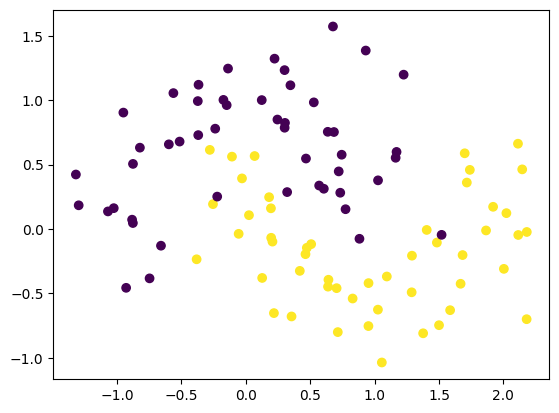

In [19]:
plt.scatter(x=df['X'],y=df['y'],c=df['class'])

In [21]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [23]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [27]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\Jatin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.get_weights()

[array([[-0.43220833,  0.09240323,  0.34136587, -0.39453968,  0.23608506,
          0.5515422 ,  0.58200985,  0.29528278, -0.5685824 ,  0.6167086 ],
        [ 0.65481454, -0.17352849,  0.42586714,  0.1836139 ,  0.4339016 ,
         -0.4969882 ,  0.18270522, -0.15587795,  0.49377412,  0.38225788]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.40119767,  0.4389583 ,  0.37720174,  0.11591774, -0.32478052,
          0.4145643 ,  0.37456506,  0.05736369, -0.0928342 ,  0.37101352],
        [-0.20720407, -0.08169368, -0.4759543 ,  0.5301454 , -0.03227675,
         -0.4743055 ,  0.08413321,  0.28315467, -0.26267806,  0.24218237],
        [-0.53918964, -0.3422407 ,  0.11792797,  0.04247314,  0.23131192,
         -0.24194524,  0.28643072, -0.15358666,  0.20589924,  0.009574  ],
        [ 0.48598146,  0.4591905 , -0.443942  ,  0.48889983, -0.15951335,
          0.10776424,  0.03818959, -0.32506508, -0.49740836, -0.5353492 ],
        [-0.12394

In [33]:
initial_weights = model.get_weights()

In [35]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [37]:
model.set_weights(initial_weights)

In [45]:
model.get_weights()

[array([[-0.15798838, -0.86264294,  0.06447749, -1.0058328 ,  0.24850196,
          0.71127266,  0.8927894 , -0.11538604, -0.7584703 , -0.2771901 ],
        [-1.0355675 ,  0.11160978, -0.37124076, -1.0333011 ,  0.2897416 ,
          0.42133367, -1.1908946 ,  0.02783446, -0.9417043 , -0.21105474]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-2.5587627e-01, -5.3884286e-01,  1.7520249e-01, -3.4858223e-02,
          2.3672496e-01,  7.4019587e-01, -1.3702282e-01, -4.4032115e-01,
          3.2239658e-01, -8.6676538e-01],
        [-6.1548460e-01, -4.9755287e-01,  2.8182444e-01, -3.5779837e-01,
          3.1603181e-03, -2.5722142e-02, -1.4665826e-01, -2.4809189e-01,
         -1.9218302e-01,  4.0448007e-01],
        [ 2.6264068e-01,  6.4119911e-01,  3.8905686e-01,  3.3313474e-01,
          3.1074369e-01, -4.9438239e-03,  4.0043736e-01,  2.3643691e-02,
         -5.4466921e-01,  1.4776574e-01],
        [ 5.3946304e-01, -2.1820682e-01,  5.39793

In [47]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [49]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.5582 - loss: 0.6883 - val_accuracy: 0.6000 - val_loss: 0.6919
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6075 - loss: 0.6857 - val_accuracy: 0.6500 - val_loss: 0.6887
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6100 - loss: 0.6819 - val_accuracy: 0.6500 - val_loss: 0.6864
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6046 - loss: 0.6807 - val_accuracy: 0.6500 - val_loss: 0.6842
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6046 - loss: 0.6774 - val_accuracy: 0.6500 - val_loss: 0.6823
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5811 - loss: 0.6750 - val_accuracy: 0.6500 - val_loss: 0.6803
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6358 - loss: 0.6702 - val_accuracy: 0.6500 - val_loss: 0.6782
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6163 - loss: 0.6683 - val_accuracy: 0.6500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 565us/step


<Axes: >

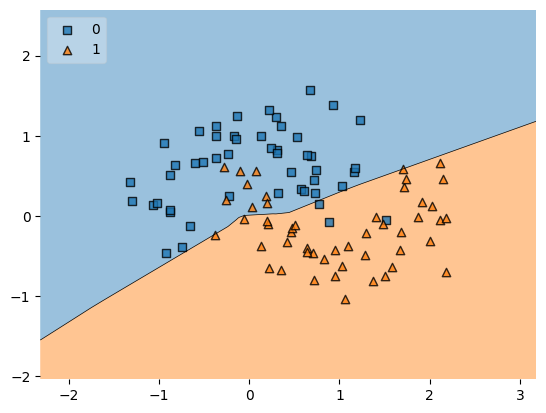

In [51]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [53]:
#for he normal would be use in relu 
# model = Sequential()

# model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
# model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
# model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
# model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
# model.add(Dense(1,activation='sigmoid'))
